# STEX Hypergraph Representation Benchmark

This notebook benchmarks six unsupervised hypergraph representations:

- **CIHI**: an edge-curvature histogram for each hypergraph.
- **HORC**: an edge-curvature histogram for each hypergraph, using the available weighted-clique configuration.
- **HGNN**: a learned graph embedding from the shared unsupervised HNN trainer.
- **HyperGCN**: a learned graph embedding from the same unsupervised trainer.
- **HGNN + node CIHI** and **HyperGCN + node CIHI**: curvature-informed variants that append each node's mean incident-edge CIHI to its initial features.

Every representation follows the same evaluation order: fit KPCA on all STEX hypergraphs, filter to the target categories, then run KMeans and calculate ARI/AMI.

## Conventions

- Labels are never used to train HGNN or HyperGCN.
- CIHI and HFRC are obtained from `HypergraphDataset`.
- HORC is loaded from the four TSV batches in `code/stex/horc`.
- The TSV results use weighted-clique dispersion, mean aggregation, and $\alpha=0.1$.
- KPCA is fitted before category filtering for all six methods.
- KMeans uses three clusters, `random_state=42`, and `n_init=20`.
- The evaluated categories are Religion, Language, and Nerds.
- Restart the kernel before running this notebook after changing files under `src/HNN`.

In [10]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from plotnine import *
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
from tqdm.auto import tqdm

candidates = [Path.cwd(), Path.cwd() / "code", *Path.cwd().parents]
CODE_ROOT = next(p for p in candidates if (p / "src" / "__init__.py").is_file())
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from src import load_data
from src.HNN import HNNConfig, fit_hypergraph_embeddings
from src.hyg_cluster import cihi_histogram, horc_histogram, kpca

DATA_ROOT = CODE_ROOT.parent / "data"
ZISSOU1_CONTINUOUS = [
    "#3A9AB2", "#6FB2C1", "#91BAB6", "#A5C2A3", "#BDC881",
    "#DCCB4E", "#E3B710", "#E79805", "#EC7A05", "#EF5703", "#F11B00",
]

/Users/shiyi/.virtualenvs/lower-ricci/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Load STEX and edge curvatures

In [11]:
ds = load_data(dname="stex", data_folder=DATA_ROOT)
cihi = np.asarray([np.nan if x is None else x for x in ds.get_cihi()], dtype=float)
hfrc = np.asarray([np.nan if x is None else x for x in ds.get_hfrc()], dtype=float)

HORC_DIR = CODE_ROOT / "stex" / "horc"
horc_paths = sorted(HORC_DIR.glob("stex_*_horc.tsv"), key=lambda p: int(p.stem.split("_")[1]))
if not horc_paths:
    raise FileNotFoundError(f"No HORC TSV files found in {HORC_DIR}")

horc = pd.concat([
    pd.read_csv(path, sep="\t", usecols=["hg_idx", "horc"],
                dtype={"hg_idx": "int32", "horc": "float64"})
    for path in horc_paths
], ignore_index=True).sort_values("hg_idx", kind="stable").reset_index(drop=True)

dataset_hg_idx = np.asarray(ds.hypergraph_idx, dtype=np.int32)
assert len(cihi) == len(hfrc) == len(horc) == len(ds.hyperedges)
assert np.array_equal(horc["hg_idx"].to_numpy(), dataset_hg_idx)

horc_values = horc["horc"].to_numpy()
HORC_CONFIGURATION = "w_clique / mean / alpha=0.1"
del dataset_hg_idx
print(ds)
print(f"Loaded {len(horc_paths)} HORC files ({len(horc):,} hyperedges)")

HypergraphDataset(num_hyperedges=6689705, num_nodes=5889, num_hypergraphs=355, node_labels=no, edge_labels=no, hypergraph_labels=yes, max_dv=59250, max_de=7, perc_de2=29.4%)
Unique Hypergraph labels (355): ['3dprinting', '3dprinting.meta', 'academia', 'academia.meta', 'ai', 'ai.meta', 'alcohol', 'alcohol.meta', 'android', 'android.meta']
Loaded 4 HORC files (6,689,705 hyperedges)


## Correlation analysis

The heatmap compares the three available edge-level curvature metrics.

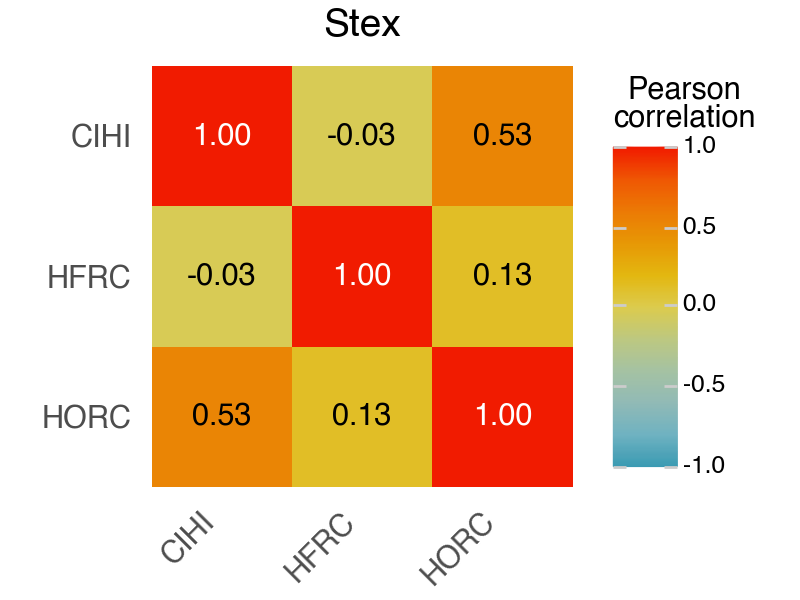

In [12]:
curvature = {"CIHI": cihi, "HFRC": hfrc, "HORC": horc_values}
corr_order = list(curvature)
corr = pd.DataFrame(np.eye(len(corr_order)), index=corr_order, columns=corr_order)
for i, metric_y in enumerate(corr_order):
    for metric_x in corr_order[i + 1:]:
        values_x, values_y = curvature[metric_x], curvature[metric_y]
        valid = np.isfinite(values_x) & np.isfinite(values_y)
        value = np.corrcoef(values_x[valid], values_y[valid])[0, 1]
        corr.loc[metric_y, metric_x] = corr.loc[metric_x, metric_y] = value

corr_long = pd.DataFrame(
    [(y, x, corr.loc[y, x]) for y in corr.index for x in corr.columns],
    columns=["metric_y", "metric_x", "correlation"],
)
corr_long["label"] = corr_long["correlation"].map(lambda x: f"{x:.2f}")
corr_long["text_color"] = np.where(corr_long["correlation"].abs() > 0.75, "white", "black")
corr_long["metric_x"] = pd.Categorical(corr_long["metric_x"], corr_order, ordered=True)
corr_long["metric_y"] = pd.Categorical(corr_long["metric_y"], corr_order[::-1], ordered=True)

p_corr = (
    ggplot(corr_long, aes("metric_x", "metric_y", fill="correlation"))
    + geom_tile()
    + geom_text(aes(label="label", color="text_color"), size=11)
    + scale_fill_gradientn(colors=ZISSOU1_CONTINUOUS, limits=(-1, 1), name="Pearson\ncorrelation")
    + scale_color_identity()
    + coord_equal()
    + labs(title=r"Stex", x="", y="")
    + theme_minimal()
    + theme(
        figure_size=(4, 3),
        plot_title=element_text(size=14, ha="center"),
        axis_text_x=element_text(rotation=45, ha="right", size=11),
        axis_text_y=element_text(size=11),
        panel_grid=element_blank(),
    )
)
p_corr

In [13]:
p_corr.save(
    CODE_ROOT / "stex" / "stex_corr.pdf",
    width=4,
    height=3,
    units="in",
    verbose=False,
)

## Evaluation labels and shared helpers

The target STEX sites are mapped to the same three categories used in the original analysis.

In [14]:
category_groups = {
    "Religion": ["islam", "hinduism", "buddhism", "judaism", "christianity"],
    "Language": [
        "japanese", "chinese", "italian", "spanish", "french", "german",
        "english", "korean", "rus", "esperanto", "conlang", "latin", "ukrainian",
    ],
    "Nerds": ["rpg", "scifi", "boardgames", "anime", "gaming"],
}
category_colors = dict(zip(
    category_groups,
    [ZISSOU1_CONTINUOUS[1], ZISSOU1_CONTINUOUS[4], ZISSOU1_CONTINUOUS[7]],
))
site_to_category = {site: category for category, sites in category_groups.items() for site in sites}

site_labels = np.asarray(ds.hypergraph_labels)
category_mask = np.isin(site_labels, list(site_to_category))
selected_sites = site_labels[category_mask]
true_categories = np.asarray([site_to_category[site] for site in selected_sites])
pd.DataFrame({"site": selected_sites, "category": true_categories})

,site,category
0,anime,Nerds
1,boardgames,Nerds
2,buddhism,Religion
3,chinese,Language
4,christianity,Religion
5,conlang,Language
6,english,Language
7,esperanto,Language
8,french,Language
9,gaming,Nerds


In [15]:
edge_hg_idx = np.asarray(ds.hypergraph_idx)
starts = np.r_[0, np.flatnonzero(edge_hg_idx[1:] != edge_hg_idx[:-1]) + 1]
stops = np.r_[starts[1:], len(edge_hg_idx)]
hg_order = edge_hg_idx[starts]

assert len(hg_order) == len(site_labels) == len(category_mask)

def curvature_representation(values, histogram_function):
    values = np.asarray(values, dtype=float)
    representation = histogram_function([
        values[start:stop] for start, stop in zip(starts, stops)
    ])
    if not np.isfinite(representation).all():
        raise ValueError("Curvature histogram contains non-finite values.")
    return representation

def evaluate_kmeans(embedding, labels):
    predicted = KMeans(
        n_clusters=3, random_state=42, n_init=20
    ).fit_predict(embedding)
    scores = {
        "ARI": adjusted_rand_score(labels, predicted),
        "AMI": adjusted_mutual_info_score(labels, predicted),
    }
    return scores, predicted

## CIHI and HORC histogram representations

In [16]:
cihi_representation = curvature_representation(cihi, cihi_histogram)
horc_representation = curvature_representation(horc_values, horc_histogram)

print("CIHI representation:", cihi_representation.shape)
print("HORC representation:", horc_representation.shape)

CIHI representation: (355, 40)
HORC representation: (355, 60)


## Learn HGNN and HyperGCN representations

The learned embeddings are cached because training is substantially more expensive than KPCA. Set `RETRAIN_HNN=True` after changing model or training settings. STEX has more than 512 global node identities, so `feature_mode="auto"` uses constant-plus-standardized-log-degree node features.

In [17]:
HNN_RANDOM_STATE = 42
HNN_METHODS = ("hgnn", "hypergcn")
hnn_config = HNNConfig(
    embedding_dim=64,
    hidden_dim=128,
    num_layers=2,
    epochs=50,
    batch_size=32,
)
HNN_CACHE = CODE_ROOT / "stex" / (
    f"hnn_embeddings_d{hnn_config.embedding_dim}_h{hnn_config.hidden_dim}_"
    f"l{hnn_config.num_layers}_e{hnn_config.epochs}_b{hnn_config.batch_size}_"
    f"seed{HNN_RANDOM_STATE}.npz"
)
RETRAIN_HNN = False

if HNN_CACHE.exists() and not RETRAIN_HNN:
    with np.load(HNN_CACHE, allow_pickle=False) as cached:
        cached_hg_order = cached["hypergraph_ids"]
        hnn_representations = {method: cached[method] for method in HNN_METHODS}
    if not np.array_equal(cached_hg_order, hg_order):
        raise ValueError("Cached HNN hypergraph order does not match STEX.")
    print(f"Loaded HNN embeddings from {HNN_CACHE}")
else:
    hnn_results = {}
    for method in HNN_METHODS:
        print(f"\nTraining {method.upper()}")
        hnn_results[method] = fit_hypergraph_embeddings(
            ds,
            method=method,
            config=hnn_config,
            feature_mode="auto",
            device="cpu",
            random_state=HNN_RANDOM_STATE,
        )
        if not np.array_equal(np.asarray(hnn_results[method].hypergraph_ids), hg_order):
            raise ValueError(f"{method} hypergraph order does not match STEX.")
    hnn_representations = {
        method: result.embeddings for method, result in hnn_results.items()
    }
    np.savez_compressed(
        HNN_CACHE,
        hypergraph_ids=hg_order,
        **hnn_representations,
    )
    print(f"Saved HNN embeddings to {HNN_CACHE}")

for method, representation in hnn_representations.items():
    print(method, representation.shape)


Training HGNN
Epoch 001/50: loss=2.857203
Epoch 005/50: loss=2.386781
Epoch 010/50: loss=2.262723
Epoch 015/50: loss=2.312182
Epoch 020/50: loss=2.164563
Epoch 025/50: loss=2.193687
Epoch 030/50: loss=2.171581
Epoch 035/50: loss=2.194162
Epoch 040/50: loss=2.142027
Epoch 045/50: loss=2.121922
Epoch 050/50: loss=2.111725

Training HYPERGCN
HyperGCN preprocessing 1/355
HyperGCN preprocessing 250/355
HyperGCN preprocessing 355/355
Epoch 001/50: loss=2.837540
Epoch 005/50: loss=2.103272
Epoch 010/50: loss=1.558526
Epoch 015/50: loss=1.462386
Epoch 020/50: loss=1.444717
Epoch 025/50: loss=1.318544
Epoch 030/50: loss=1.414663
Epoch 035/50: loss=1.311706
Epoch 040/50: loss=1.273410
Epoch 045/50: loss=1.313824
Epoch 050/50: loss=1.250134
Saved HNN embeddings to /Users/shiyi/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Research/CIHI/Lower Ricci Curvature for Hypergraph/code/stex/hnn_embeddings_d64_h128_l2_e50_b32_seed42.npz
hgnn (355, 64)
hypergcn (355, 64)


## CIHI-informed node initialization

For each node $v$, define $c_v=|E_v^{\mathrm{fin}}|^{-1}\sum_{e\in E_v^{\mathrm{fin}}}c_e$, where $E_v^{\mathrm{fin}}$ contains incident hyperedges with finite CIHI. Nodes without any finite incident CIHI are assigned the global mean. The globally standardized $c_v$ is appended to STEX's constant-plus-standardized-log-degree feature, producing three-dimensional initial node features.

In [18]:
CIHI_NODE_CACHE = CODE_ROOT / "stex" / (
    f"hnn_node_cihi_d{hnn_config.embedding_dim}_h{hnn_config.hidden_dim}_"
    f"l{hnn_config.num_layers}_e{hnn_config.epochs}_b{hnn_config.batch_size}_"
    f"seed{HNN_RANDOM_STATE}.npz"
)
RETRAIN_CIHI_NODE_HNN = False

if CIHI_NODE_CACHE.exists() and not RETRAIN_CIHI_NODE_HNN:
    with np.load(CIHI_NODE_CACHE, allow_pickle=False) as cached:
        cached_hg_order = cached["hypergraph_ids"]
        cihi_node_representations = {method: cached[method] for method in HNN_METHODS}
    if not np.array_equal(cached_hg_order, hg_order):
        raise ValueError("Cached CIHI-node hypergraph order does not match STEX.")
    print(f"Loaded CIHI-node embeddings from {CIHI_NODE_CACHE}")
else:
    cihi_node_results = {}
    for method in HNN_METHODS:
        print(f"\nTraining {method.upper()} + node CIHI")
        cihi_node_results[method] = fit_hypergraph_embeddings(
            ds,
            method=method,
            config=hnn_config,
            feature_mode="auto",
            hyperedge_curvatures=cihi,
            standardize_node_curvature=True,
            device="cpu",
            random_state=HNN_RANDOM_STATE,
        )
        if not np.array_equal(np.asarray(cihi_node_results[method].hypergraph_ids), hg_order):
            raise ValueError(f"{method} + node CIHI order does not match STEX.")
    cihi_node_representations = {
        method: result.embeddings for method, result in cihi_node_results.items()
    }
    np.savez_compressed(
        CIHI_NODE_CACHE,
        hypergraph_ids=hg_order,
        **cihi_node_representations,
    )
    print(f"Saved CIHI-node embeddings to {CIHI_NODE_CACHE}")

for method, representation in cihi_node_representations.items():
    print(f"{method} + node CIHI", representation.shape)


Training HGNN + node CIHI
Epoch 001/50: loss=2.366598
Epoch 005/50: loss=1.524285
Epoch 010/50: loss=1.311543
Epoch 015/50: loss=1.269272
Epoch 020/50: loss=1.284087
Epoch 025/50: loss=1.197584
Epoch 030/50: loss=1.125588
Epoch 035/50: loss=1.084559
Epoch 040/50: loss=1.056719
Epoch 045/50: loss=1.090777
Epoch 050/50: loss=1.056011

Training HYPERGCN + node CIHI
HyperGCN preprocessing 1/355
HyperGCN preprocessing 250/355
HyperGCN preprocessing 355/355
Epoch 001/50: loss=2.564171
Epoch 005/50: loss=1.531025
Epoch 010/50: loss=1.258268
Epoch 015/50: loss=1.165617
Epoch 020/50: loss=1.090471
Epoch 025/50: loss=1.064007
Epoch 030/50: loss=0.990019
Epoch 035/50: loss=0.965030
Epoch 040/50: loss=0.914112
Epoch 045/50: loss=0.913022
Epoch 050/50: loss=0.900570
Saved CIHI-node embeddings to /Users/shiyi/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Research/CIHI/Lower Ricci Curvature for Hypergraph/code/stex/hnn_node_cihi_d64_h128_l2_e50_b32_seed42.npz
hgnn + node CIHI (355, 64)
hyperg

## Shared KPCA and KMeans benchmark

In [19]:
kpca_embeddings_all = {
    "CIHI": kpca(cihi_representation, 2),
    "HORC": kpca(horc_representation, 2),
    "HGNN": kpca(hnn_representations["hgnn"], 2),
    "HyperGCN": kpca(hnn_representations["hypergcn"], 2),
    "HGNN + node CIHI": kpca(cihi_node_representations["hgnn"], 2),
    "HyperGCN + node CIHI": kpca(cihi_node_representations["hypergcn"], 2),
}

method_order = [
    "CIHI", "HORC", "HGNN", "HyperGCN",
    "HGNN + node CIHI", "HyperGCN + node CIHI",
]
method_configurations = {
    "CIHI": "CIHI histogram",
    "HORC": HORC_CONFIGURATION,
    "HGNN": "constant + standardized log-degree",
    "HyperGCN": "constant + standardized log-degree",
    "HGNN + node CIHI": "constant + standardized log-degree + mean incident CIHI",
    "HyperGCN + node CIHI": "constant + standardized log-degree + mean incident CIHI",
}
selected_embeddings = {}
predictions = {}
benchmark_records = []

for method in method_order:
    selected = kpca_embeddings_all[method][category_mask]
    scores, predicted = evaluate_kmeans(selected, true_categories)
    selected_embeddings[method] = selected
    predictions[method] = predicted
    benchmark_records.append({
        "method": method,
        "configuration": method_configurations[method],
        **scores,
    })

benchmark_summary = pd.DataFrame(benchmark_records)
benchmark_summary["method"] = pd.Categorical(
    benchmark_summary["method"], method_order, ordered=True
)
benchmark_summary

,method,configuration,ARI,AMI
0,CIHI,CIHI histogram,0.535873,0.438143
1,HORC,w_clique / mean / alpha=0.1,0.323048,0.302526
2,HGNN,constant + standardized log-degree,0.271129,0.434638
3,HyperGCN,constant + standardized log-degree,0.260210,0.438396
4,HGNN + node CIHI,constant + standardized log-degree + mean inci...,0.428933,0.459648
5,HyperGCN + node CIHI,constant + standardized log-degree + mean inci...,0.349793,0.422743


## KPCA embedding comparison

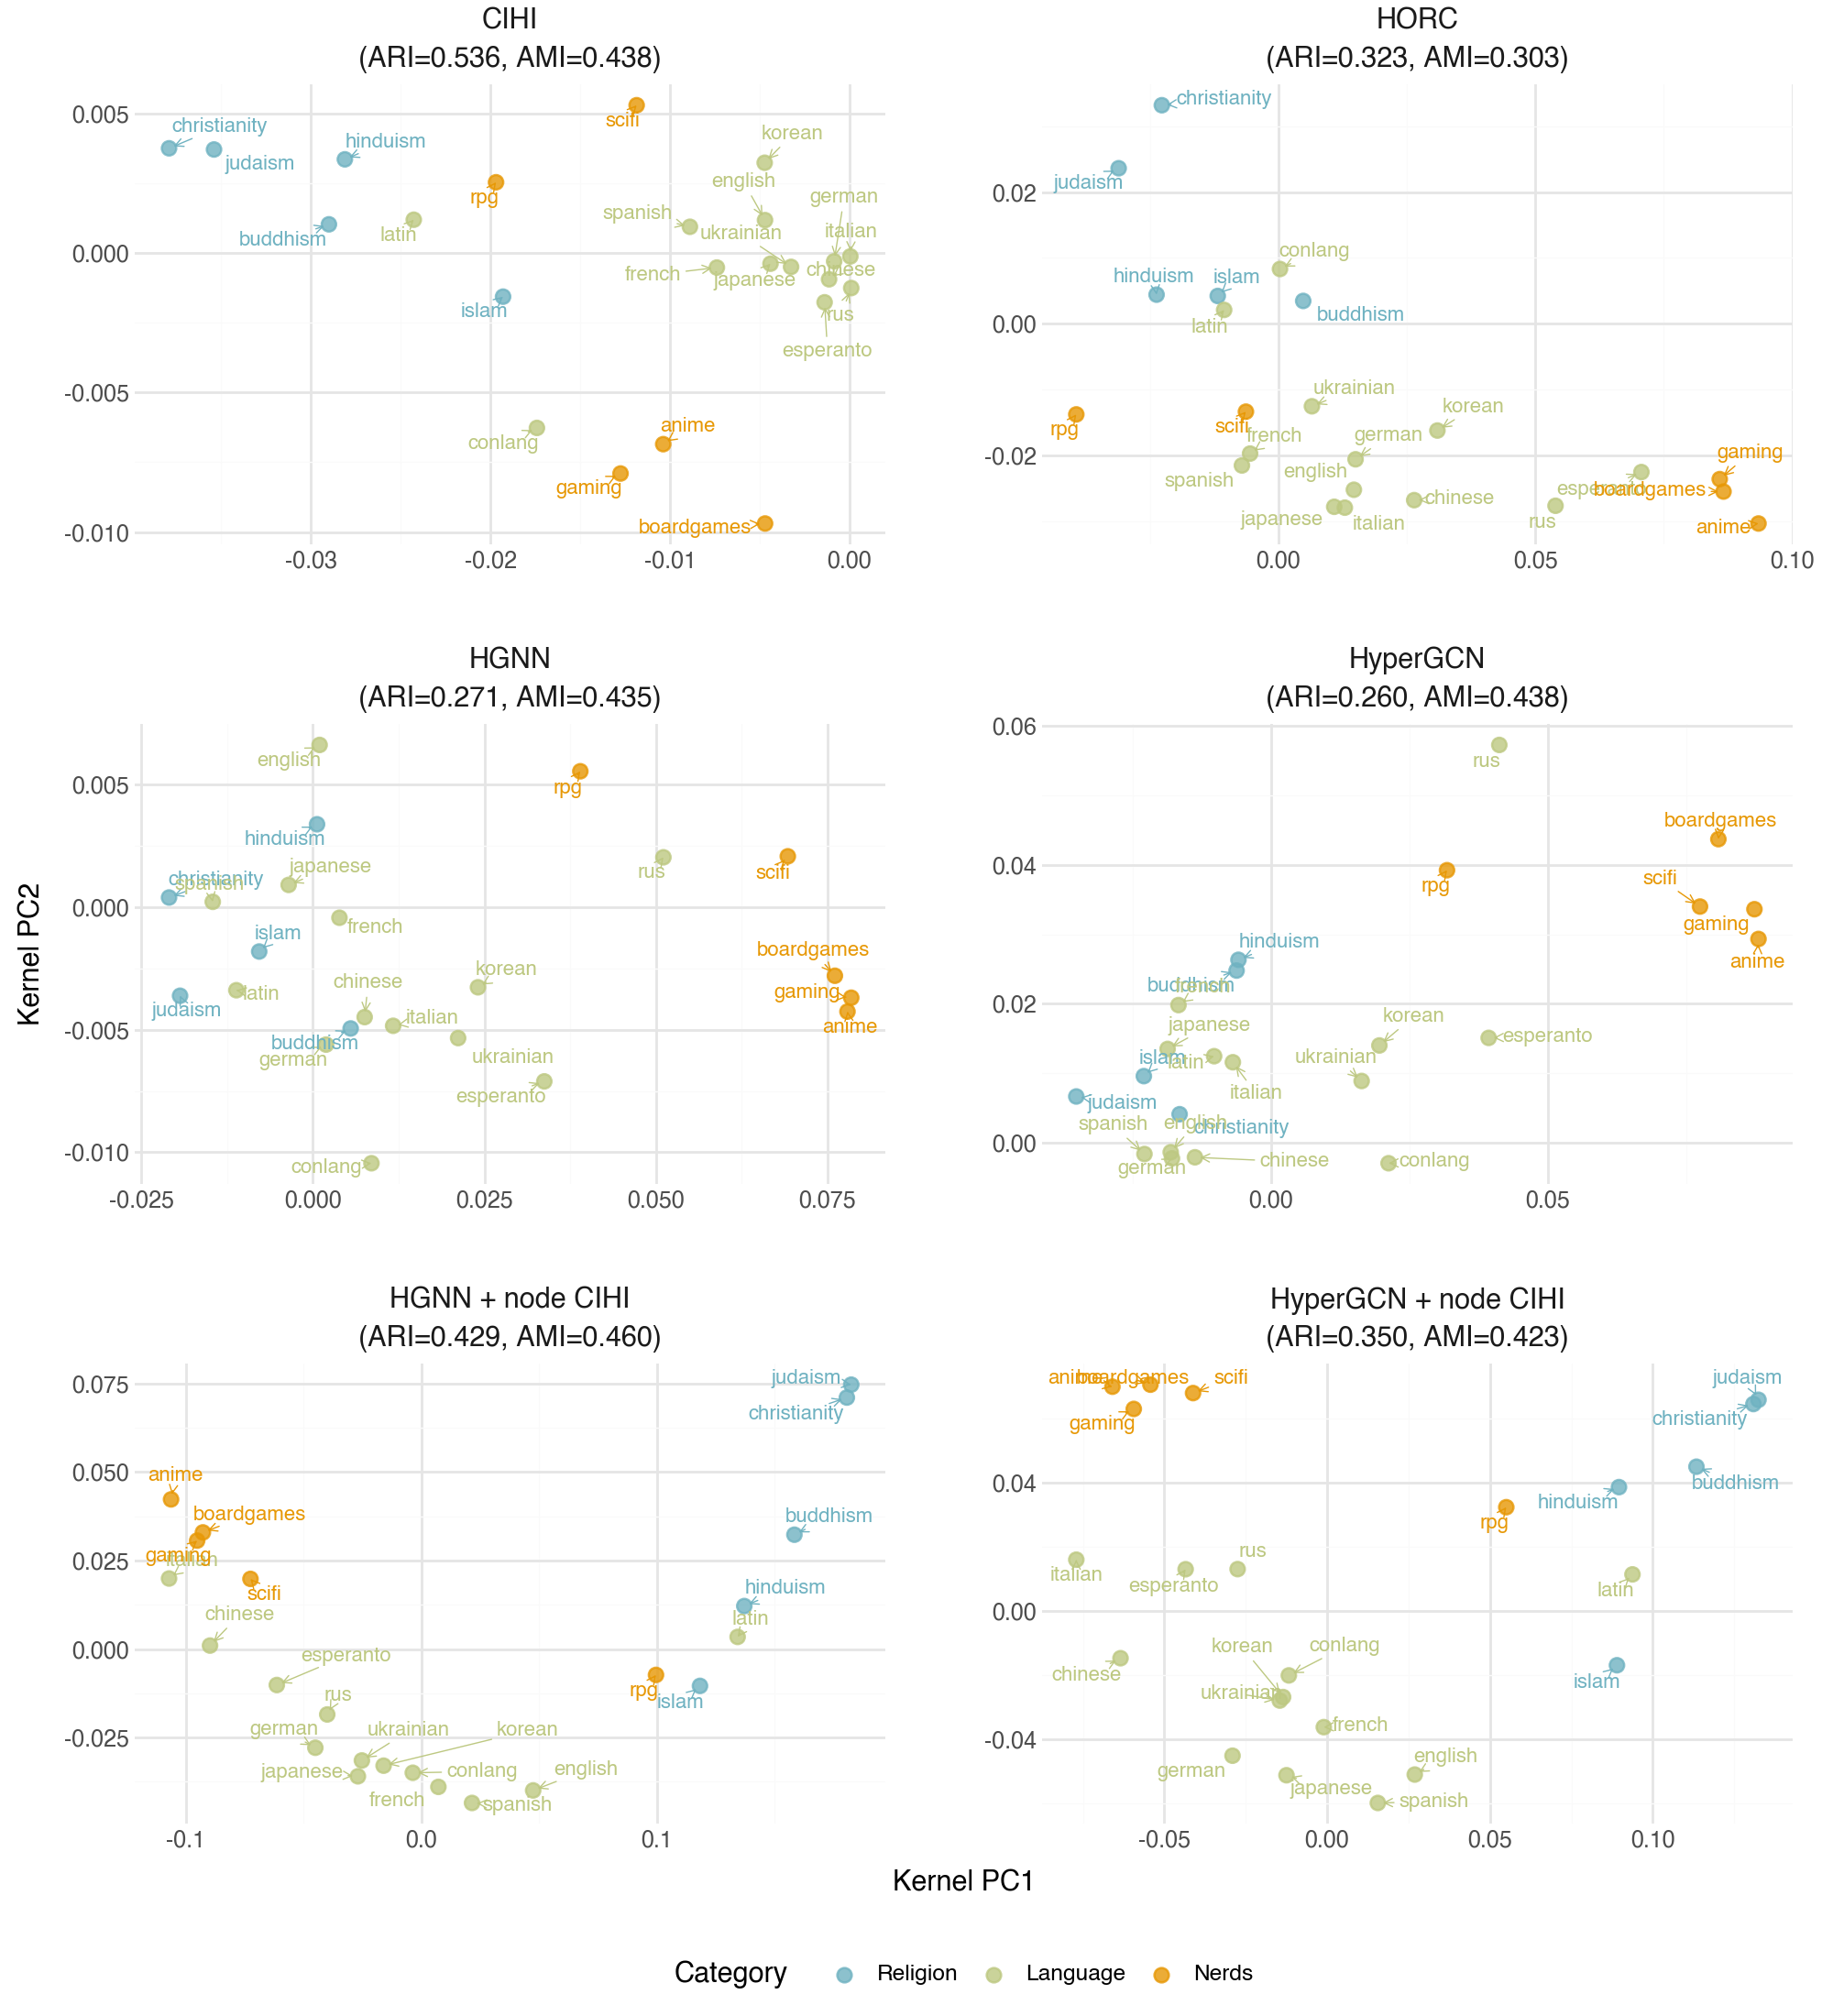

In [20]:
score_lookup = benchmark_summary.set_index("method")[["ARI", "AMI"]].to_dict("index")
facet_titles = {
    method: (
        f"{method}\n(ARI={score_lookup[method]['ARI']:.3f}, "
        f"AMI={score_lookup[method]['AMI']:.3f})"
    )
    for method in method_order
}

embedding_plot_data = pd.concat([
    pd.DataFrame({
        "Kernel PC1": selected_embeddings[method][:, 0],
        "Kernel PC2": selected_embeddings[method][:, 1],
        "method": facet_titles[method],
        "category": true_categories,
        "site": selected_sites,
    })
    for method in method_order
], ignore_index=True)
embedding_plot_data["method"] = pd.Categorical(
    embedding_plot_data["method"],
    [facet_titles[method] for method in method_order],
    ordered=True,
)
embedding_plot_data["category"] = pd.Categorical(
    embedding_plot_data["category"], list(category_groups), ordered=True
)

p_embeddings = (
    ggplot(embedding_plot_data, aes("Kernel PC1", "Kernel PC2", color="category"))
    + geom_point(size=2.7, alpha=0.8)
    + geom_text(
        aes(label="site"),
        size=8,
        show_legend=False,
        adjust_text={"expand": (1, 1.1)},
    )
    + facet_wrap("method", ncol=2, scales="free")
    + scale_color_manual(values=category_colors)
    + labs(color="Category")
    + theme_minimal()
    + theme(
        figure_size=(10, 11),
        legend_position="bottom",
        panel_spacing_x=0.05,
        panel_spacing_y=0.05,
        strip_text=element_text(size=11, ha="center"),
        axis_title=element_text(size=11),
        axis_text=element_text(size=9),
    )
)
p_embeddings

In [24]:
p_embeddings.save(
    CODE_ROOT / "stex" / "stex_embeddings.pdf",
    width=10,
    height=10,
    units="in",
    verbose=False,
)

## ARI and AMI comparison

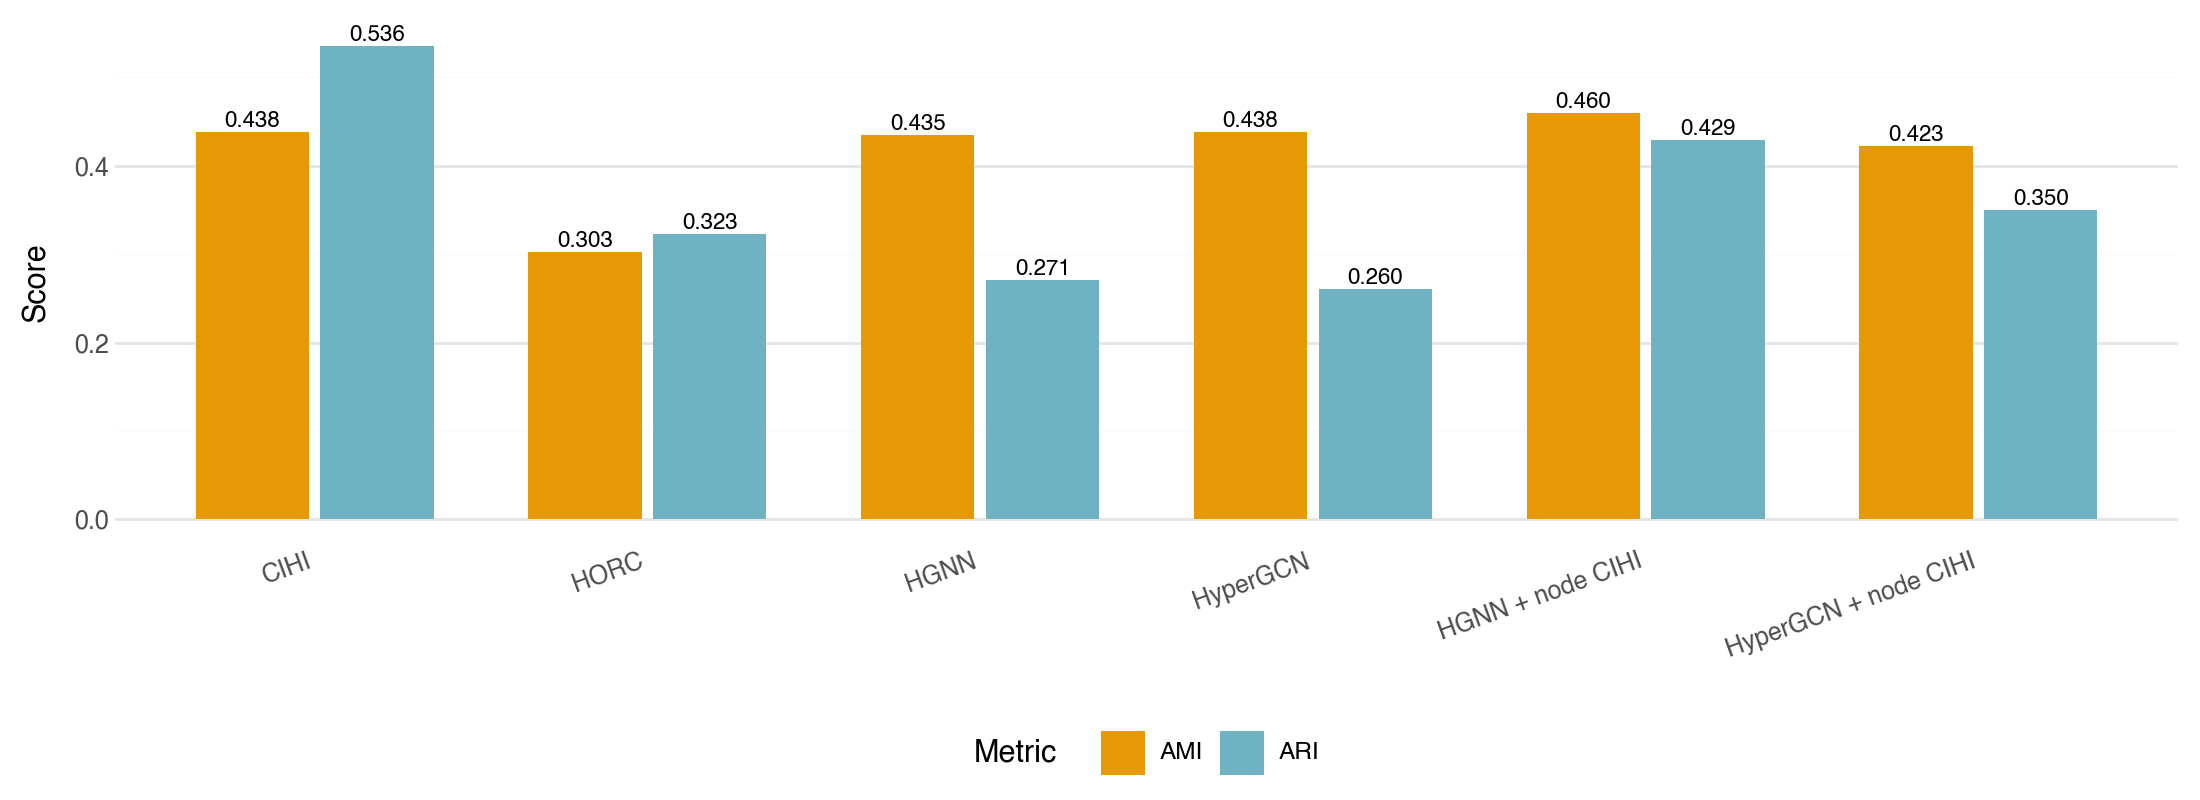

In [22]:
score_plot_data = benchmark_summary.melt(
    id_vars=["method", "configuration"],
    value_vars=["ARI", "AMI"],
    var_name="score_type",
    value_name="score",
)
score_plot_data["label"] = score_plot_data["score"].map(lambda value: f"{value:.3f}")

p_scores = (
    ggplot(score_plot_data, aes("method", "score", fill="score_type"))
    + geom_col(position=position_dodge(width=0.75), width=0.68)
    + geom_text(
        aes(label="label"),
        position=position_dodge(width=0.75),
        va="bottom",
        size=8,
    )
    + scale_fill_manual(values={"ARI": ZISSOU1_CONTINUOUS[1], "AMI": ZISSOU1_CONTINUOUS[7]})
    + labs(x="", y="Score", fill="Metric")
    + theme_minimal()
    + theme(
        figure_size=(11, 4),
        legend_position="bottom",
        axis_text_x=element_text(rotation=20, ha="right", size=9),
        axis_text_y=element_text(size=9),
        axis_title_y=element_text(size=11),
        panel_grid_major_x=element_blank(),
    )
)
p_scores